In [9]:
import numpy as np
import pandas as pd

np.random.seed(42)

# --- CONFIGURACIÓN GLOBAL (22 PAÍSES) ---
# Hemisferio: 'N' (Norte), 'S' (Sur), 'T' (Tropical/Monzónico)
# Pago: 'cash', 'card', 'digital_wallet' (incluye UPI, PIX, M-Pesa, Alipay)
# Transporte: 'luxury_bus', 'tourist_van', 'train_express'

paises_config = {
    'Morocco':      {'hemisferio': 'N', 'atractivo': 110, 'pago_pref': 'cash',           'transporte_top': 'tourist_van'},
    'Germany':      {'hemisferio': 'N', 'atractivo': 190, 'pago_pref': 'card',           'transporte_top': 'train_express'},
    'South Africa': {'hemisferio': 'S', 'atractivo': 120, 'pago_pref': 'card',           'transporte_top': 'luxury_bus'},
    'Australia':    {'hemisferio': 'S', 'atractivo': 140, 'pago_pref': 'card',           'transporte_top': 'tourist_van'},
    'Mexico':       {'hemisferio': 'N', 'atractivo': 160, 'pago_pref': 'cash',           'transporte_top': 'luxury_bus'},
    'Thailand':     {'hemisferio': 'T', 'atractivo': 180, 'pago_pref': 'cash',           'transporte_top': 'tourist_van'},
    'Spain':        {'hemisferio': 'N', 'atractivo': 210, 'pago_pref': 'card',           'transporte_top': 'train_express'},
    'Brazil':       {'hemisferio': 'S', 'atractivo': 170, 'pago_pref': 'digital_wallet', 'transporte_top': 'luxury_bus'}, # Por el uso masivo de PIX
    'New Zealand':  {'hemisferio': 'S', 'atractivo': 110, 'pago_pref': 'card',           'transporte_top': 'tourist_van'},
    'Kenya':        {'hemisferio': 'T', 'atractivo': 90,  'pago_pref': 'digital_wallet', 'transporte_top': 'tourist_van'}, # Por el uso masivo de M-Pesa
    'China':        {'hemisferio': 'N', 'atractivo': 240, 'pago_pref': 'digital_wallet', 'transporte_top': 'train_express'}, # WeChat/Alipay + Alta Velocidad
    'Japan':        {'hemisferio': 'N', 'atractivo': 200, 'pago_pref': 'card',           'transporte_top': 'train_express'},
    'Italy':        {'hemisferio': 'N', 'atractivo': 210, 'pago_pref': 'card',           'transporte_top': 'train_express'},
    'Peru':         {'hemisferio': 'S', 'atractivo': 100, 'pago_pref': 'cash',           'transporte_top': 'tourist_van'},
    'Vietnam':      {'hemisferio': 'T', 'atractivo': 130, 'pago_pref': 'cash',           'transporte_top': 'tourist_van'},
    'India':        {'hemisferio': 'T', 'atractivo': 250, 'pago_pref': 'digital_wallet', 'transporte_top': 'train_express'}, # UPI
    'Greece':       {'hemisferio': 'N', 'atractivo': 140, 'pago_pref': 'card',           'transporte_top': 'luxury_bus'},
    'Canada':       {'hemisferio': 'N', 'atractivo': 150, 'pago_pref': 'card',           'transporte_top': 'luxury_bus'},
    'France':       {'hemisferio': 'N', 'atractivo': 230, 'pago_pref': 'card',           'transporte_top': 'train_express'},
    'Argentina':    {'hemisferio': 'S', 'atractivo': 120, 'pago_pref': 'cash',           'transporte_top': 'luxury_bus'},
    'USA':          {'hemisferio': 'N', 'atractivo': 250, 'pago_pref': 'card',           'transporte_top': 'luxury_bus'},
    'Egypt':        {'hemisferio': 'N', 'atractivo': 150, 'pago_pref': 'cash',           'transporte_top': 'luxury_bus'}
}

paises = list(paises_config.keys())
fechas = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
car_types = ["luxury_bus", "tourist_van", "train_express"]
payment_methods = ["cash", "card", "digital_wallet"]

data_list = []

print("Generando dataset global. Esto puede tardar unos segundos...")

for pais in paises:
    cfg = paises_config[pais]

    for idx, fecha in enumerate(fechas):
        mes = fecha.month
        dia_semana = fecha.weekday()

        # --- 1. ESTACIONALIDAD CLIMÁTICA ---
        factor_estacional = 1.0
        if cfg['hemisferio'] == 'N':
            if mes in [6, 7, 8]: factor_estacional = 1.8     # Verano Norte
            elif mes in [12, 1]: factor_estacional = 1.2     # Invierno/Navidad (Pico secundario)
            elif mes in [2, 11]: factor_estacional = 0.6     # Temporada baja
        elif cfg['hemisferio'] == 'S':
            if mes in [12, 1, 2]: factor_estacional = 1.9    # Verano Sur
            elif mes in [6, 7]: factor_estacional = 0.7      # Invierno Sur
        elif cfg['hemisferio'] == 'T':
            if mes in [11, 12, 1, 2]: factor_estacional = 1.6 # Temporada seca/fresca
            elif mes in [6, 7, 8, 9]: factor_estacional = 0.5 # Monzones/Lluvias fuertes

        # --- 2. EVENTOS ESPECIALES (Anomalías para la RNN) ---
        es_evento = 0
        factor_evento = 0

        # Año Nuevo Chino (Aprox mediados de Febrero)
        if pais in ['China', 'Vietnam', 'Thailand'] and mes == 2 and 5 <= fecha.day <= 20:
            es_evento = 1
            factor_evento = 200 # Incremento masivo

        # Navidad Global
        elif mes == 12 and 20 <= fecha.day <= 31:
            es_evento = 1
            factor_evento = 80

        # Golden Week en Japón (Finales de Abril / Principios de Mayo)
        elif pais == 'Japan' and ((mes == 4 and fecha.day >= 29) or (mes == 5 and fecha.day <= 5)):
            es_evento = 1
            factor_evento = 150

        # --- 3. TENDENCIA Y ESTACIONALIDAD SEMANAL ---
        tendencia = idx * 0.015 # Ligero crecimiento temporal del turismo post-pandemia
        # Picos de fin de semana, caídas los domingos (regreso) y valle los martes/miércoles
        estacionalidad_semanal = 30 if dia_semana in [4, 5] else (-40 if dia_semana == 6 else -10)

        for car in car_types:
            # El vehículo principal del país multiplica la demanda; los otros se usan menos
            factor_car = 2.2 if car == cfg['transporte_top'] else 0.5

            for payment in payment_methods:
                # Días de quincena (15, 30) aumentan el método de pago preferido
                if payment == cfg['pago_pref'] and fecha.day in [15, 30]:
                    factor_payment = 25
                # Fines de semana aumentan el pago con tarjeta/wallet por turistas internacionales
                elif payment in ['card', 'digital_wallet'] and dia_semana in [4, 5]:
                    factor_payment = 15
                else:
                    factor_payment = 0

                # --- 4. RUIDO ALEATORIO ---
                ruido = np.random.normal(0, 12)

                # --- CÁLCULO FINAL DE DEMANDA ---
                demanda = (cfg['atractivo'] * factor_estacional * factor_car) \
                          + tendencia + estacionalidad_semanal + factor_payment + factor_evento + ruido

                # Asegurar un mínimo de pasajeros (evitar demandas negativas)
                demanda_final = max(2, int(demanda))

                data_list.append({
                    'fecha': fecha,
                    'pais': pais,
                    'hemisferio': cfg['hemisferio'], # Feature útil para el modelo
                    'car_type': car,
                    'payment_method': payment,
                    'evento_especial': es_evento,
                    'demanda_pasajeros': demanda_final
                })

# Crear DataFrame y exportar
df_global = pd.DataFrame(data_list)
df_global.to_csv("demanda_transporte_global.csv", index=False)

print(f"Dataset generado exitosamente con {df_global.shape[0]} registros.")
print("\nMuestra de los datos (Primeros 10 registros):")
print(df_global.head(10))
print("\nMuestra de un evento especial (Golden Week en Japón):")
print(df_global[(df_global['pais'] == 'Japan') & (df_global['evento_especial'] == 1)].head(5))

Generando dataset global. Esto puede tardar unos segundos...
Dataset generado exitosamente con 144738 registros.

Muestra de los datos (Primeros 10 registros):
       fecha     pais hemisferio       car_type  payment_method  \
0 2024-01-01  Morocco          N     luxury_bus            cash   
1 2024-01-01  Morocco          N     luxury_bus            card   
2 2024-01-01  Morocco          N     luxury_bus  digital_wallet   
3 2024-01-01  Morocco          N    tourist_van            cash   
4 2024-01-01  Morocco          N    tourist_van            card   
5 2024-01-01  Morocco          N    tourist_van  digital_wallet   
6 2024-01-01  Morocco          N  train_express            cash   
7 2024-01-01  Morocco          N  train_express            card   
8 2024-01-01  Morocco          N  train_express  digital_wallet   
9 2024-01-02  Morocco          N     luxury_bus            cash   

   evento_especial  demanda_pasajeros  
0                0                 61  
1                0    

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Cargar el dataset generado en el paso anterior
df = pd.read_csv("demanda_transporte_global.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. Extraer características numéricas de la fecha (Crucial para Regresión)
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.weekday
df['es_fin_de_semana'] = df['dia_semana'].isin([4, 5]).astype(int) # Viernes y Sábados
df['dia_mes'] = df['fecha'].dt.day
# Nota: La columna 'evento_especial' ya es 0 o 1, por lo que el modelo la usará directamente.

# 3. Aplicar One-Hot Encoding a las NUEVAS variables categóricas
# Reemplazamos 'ruta', 'origen', 'destino' por 'pais' y 'hemisferio'
columnas_categoricas = ['pais', 'hemisferio', 'car_type', 'payment_method']
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 4. Definir X (características) e y (etiqueta/target)
X = df_encoded.drop(columns=['fecha', 'demanda_pasajeros'])
y = df_encoded['demanda_pasajeros']

# 5. Dividir los datos en Entrenamiento (70%) y Prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# 6. Crear y entrenar el modelo de Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# 7. Realizar predicciones y evaluar el modelo
y_pred = modelo_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Raíz del error cuadrático medio (en la misma escala que los pasajeros)
mae = mean_absolute_error(y_test, y_pred)

print(f"Total de características procesadas: {len(X.columns)}")
print(f"Algunas características: {list(X.columns)[:10]}...\n")

print("--- EVALUACIÓN DEL MODELO (REGRESIÓN LINEAL) ---")
print(f"MAE (Error Absoluto Medio): {mae:.2f} pasajeros")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} pasajeros")

Total de características procesadas: 32
Algunas características: ['evento_especial', 'mes', 'dia_semana', 'es_fin_de_semana', 'dia_mes', 'pais_Australia', 'pais_Brazil', 'pais_Canada', 'pais_China', 'pais_Egypt']...

--- EVALUACIÓN DEL MODELO (REGRESIÓN LINEAL) ---
MAE (Error Absoluto Medio): 143.37 pasajeros
RMSE (Raíz del Error Cuadrático Medio): 183.04 pasajeros


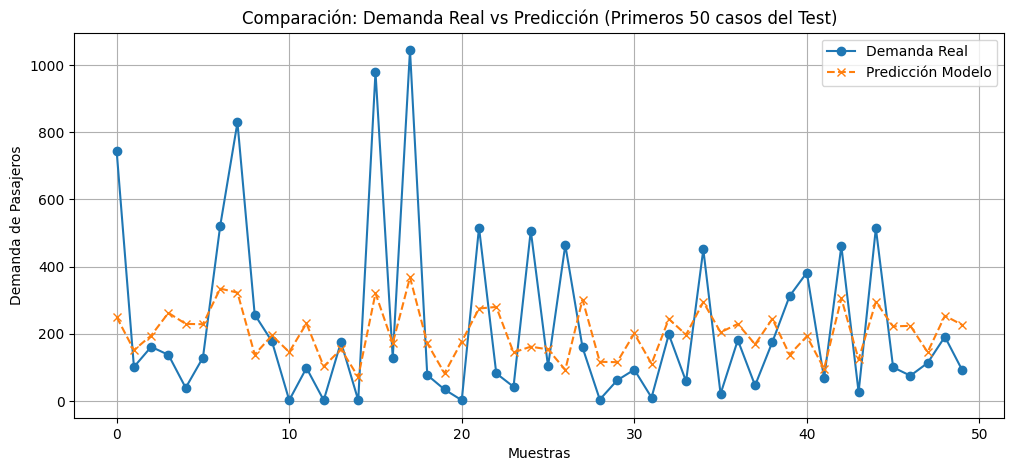

In [12]:
# 8. (Opcional) Visualización rápida de Predicciones vs Realidad para los primeros 50 casos
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:50], label='Demanda Real', marker='o')
plt.plot(y_pred[:50], label='Predicción Modelo', marker='x', linestyle='dashed')
plt.title("Comparación: Demanda Real vs Predicción (Primeros 50 casos del Test)")
plt.ylabel("Demanda de Pasajeros")
plt.xlabel("Muestras")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import tensorflow as tf

# Lista los dispositivos físicos disponibles
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", len(gpus))

if gpus:
    print("Dispositivos detectados:", gpus)
else:
    print("No se detectó ninguna GPU configurada para TensorFlow.")

GPUs disponibles: 1
Dispositivos detectados: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LayerNormalization


# --- CONFIGURACIÓN PARA USO DE GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que la memoria crezca según sea necesario
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Entrenando en GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
# -------------------------------------

# 1. Cargar y Preparar Datos (Nuevo Dataset Global)
df = pd.read_csv("demanda_transporte_global.csv")
df['fecha'] = pd.to_datetime(df['fecha'])

# 2. One-Hot Encoding a todas las variables categóricas nuevas
columnas_categoricas = ['pais', 'hemisferio', 'car_type', 'payment_method']
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=False)

# Definir las columnas que irán a la red neuronal
# ¡Ojo! Incluimos 'evento_especial' porque aporta un contexto vital a la LSTM
columnas_features = ['demanda_pasajeros', 'evento_especial'] + \
                    [col for col in df_encoded.columns if col not in ['fecha', 'demanda_pasajeros', 'evento_especial']]

# 3. Escalamiento (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
df_encoded[columnas_features] = scaler.fit_transform(df_encoded[columnas_features])

# Agregamos temporalmente las columnas originales para agrupar más fácil en el siguiente paso
df_encoded['pais_orig'] = df['pais']
df_encoded['car_orig'] = df['car_type']
df_encoded['pay_orig'] = df['payment_method']

# 4. Creación de Secuencias 3D
VENTANA = 14
X, y = [], []
fechas_y = []

# Agrupamos por país, vehículo y pago para crear líneas temporales coherentes (No mezclar Japón con México)
for (pais, car, pay), grupo in df_encoded.groupby(['pais_orig', 'car_orig', 'pay_orig']):
    # Ordenamos cronológicamente dentro de cada subgrupo
    grupo = grupo.sort_values('fecha')

    matriz_datos = grupo[columnas_features].values
    fechas_grupo = grupo['fecha'].values

    for i in range(len(matriz_datos) - VENTANA):
        X.append(matriz_datos[i : i + VENTANA])
        y.append(matriz_datos[i + VENTANA, 0]) # El índice 0 corresponde a 'demanda_pasajeros'
        fechas_y.append(fechas_grupo[i + VENTANA])

X, y, fechas_y = np.array(X), np.array(y), np.array(fechas_y)

# --- ¡CORRECCIÓN CRÍTICA DE MACHINE LEARNING! ---
# Ordenamos todo el conjunto de secuencias cronológicamente ANTES del split.
# Así nos aseguramos de entrenar con el "pasado global" y testear con el "futuro global".
indices_ordenados = np.argsort(fechas_y)
X = X[indices_ordenados]
y = y[indices_ordenados]
fechas_y = fechas_y[indices_ordenados]

# 5. División Cronológica Real
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
fechas_test = fechas_y[split_idx:]

print(f"\nForma de X_train (Secuencias 3D): {X_train.shape} -> (Muestras, Ventana Temporal, Features)")
print(f"Características introducidas a la LSTM: {len(columnas_features)}")

# 6. Arquitectura del Modelo (Optimizada para GPU)
with tf.device('/GPU:0'):
    modelo_lstm = Sequential([
        LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.4),

        LSTM(128, return_sequences=True),
        Dropout(0.4),

        LSTM(64, return_sequences=False),

        BatchNormalization(),
        Dropout(0.4),

        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    optimizador = tf.keras.optimizers.Adam(learning_rate=0.001, clipvalue=1.0)

    modelo_lstm.compile(optimizer=optimizador, loss='mse', metrics=['mae'])

# 7. Callbacks y Entrenamiento
callbacks_lista = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

print("\nIniciando entrenamiento del modelo...")
historial = modelo_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks_lista,
    verbose=1
)

# 8. Predicción y Des-escalamiento
predicciones_escaladas = modelo_lstm.predict(X_test)
matriz_inversa_pred = np.zeros((len(predicciones_escaladas), len(columnas_features)))
matriz_inversa_pred[:, 0] = predicciones_escaladas[:, 0]
y_pred_real = scaler.inverse_transform(matriz_inversa_pred)[:, 0]

matriz_inversa_test = np.zeros((len(y_test), len(columnas_features)))
matriz_inversa_test[:, 0] = y_test
y_test_real = scaler.inverse_transform(matriz_inversa_test)[:, 0]

# 9. Evaluación Final
mae_lstm = mean_absolute_error(y_test_real, y_pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-5))) * 100
accuracy_regresion = max(0, 100 - mape)

print("\n" + "="*30)
print("--- METRICAS DE EVALUACIÓN ---")
print("="*30)
print(f"MAE (Error Absoluto Medio): {mae_lstm:.2f} pasajeros")
print(f"RMSE (Raíz del Error): {rmse_lstm:.2f} pasajeros")
print(f"MAPE (Error Porcentual): {mape:.2f}%")
print(f"Precisión Equivalente: {accuracy_regresion:.2f}%")
print("="*30)

Entrenando en GPU: /physical_device:GPU:0

Forma de X_train (Secuencias 3D): (113572, 14, 33) -> (Muestras, Ventana Temporal, Features)
Características introducidas a la LSTM: 33

Iniciando entrenamiento del modelo...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 0.0299 - mae: 0.1026 - val_loss: 0.0041 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 2/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 0.0061 - mae: 0.0565 - val_loss: 0.0029 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 3/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0045 - mae: 0.0487 - val_loss: 0.0023 - val_mae: 0.0352 - learning_rate: 0.0010
Epoch 4/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0033 - mae: 0.0419 - val_loss: 0.0020 - val_mae: 0.0328 - learning_rate: 0.0010
Epoch 5/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0027 - mae: 0.0379 - val_loss: 0.0017 - val_mae: 0.0298 - learning_rate: 0.0010
Epoch 6/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 0.0022 - mae: 0.0336 - val_loss: 0.0018 - val_mae: 0.0313 - learning_rate: 0.0010
Epoch 7/50
1775/1775 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0018 - mae: 0.0300 - val_loss: 0.0013 - val_mae: 0.0254 - 

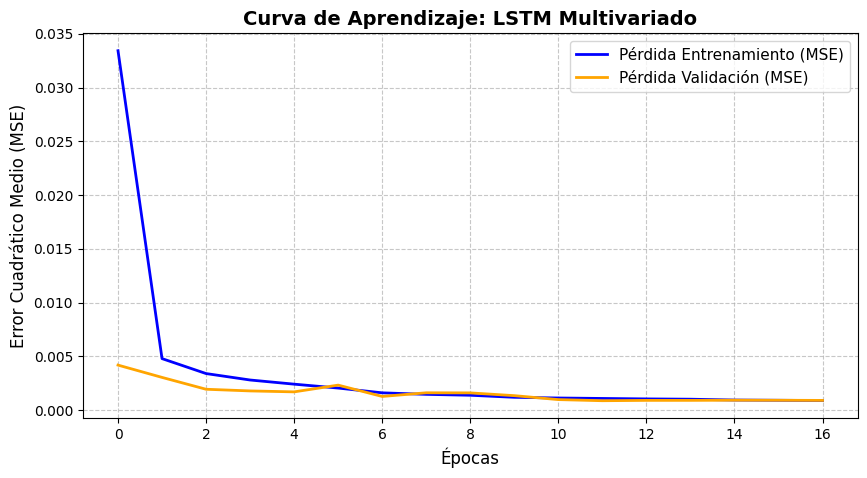

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(historial.history['loss'], label='Pérdida Entrenamiento (MSE)', color='blue', linewidth=2)
plt.plot(historial.history['val_loss'], label='Pérdida Validación (MSE)', color='orange', linewidth=2)

plt.title('Curva de Aprendizaje: LSTM Multivariado', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Guardar imagen en alta calidad
plt.savefig('curva_aprendizaje_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

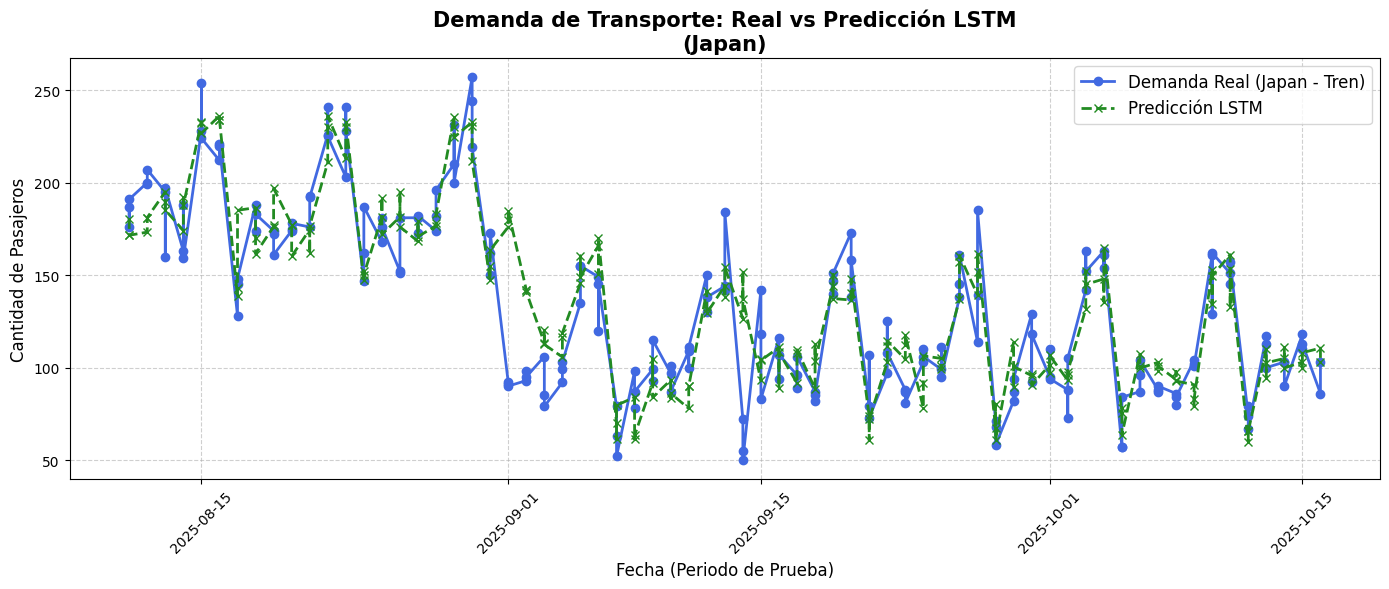

In [20]:
import matplotlib.pyplot as plt

# 1. Definir qué queremos visualizar para que la línea tenga sentido histórico
pais_objetivo = 'pais_Japan'
vehiculo_objetivo = 'car_type_luxury_bus' # El transporte más popular en Japón es el tren, pero para mostrar variedad, elegimos el segundo más popular

# Encontrar los índices de estas columnas en nuestro array de features
idx_pais = columnas_features.index(pais_objetivo)
idx_car = columnas_features.index(vehiculo_objetivo)

# 2. Crear una máscara para filtrar X_test
# Buscamos las secuencias donde, en el último día de la ventana (-1), el país y el vehículo coincidan
mascara_filtro = (X_test[:, -1, idx_pais] == 1) & (X_test[:, -1, idx_car] == 1)

# 3. Aplicar el filtro a las fechas y resultados
fechas_plot = fechas_test[mascara_filtro]
y_real_plot = y_test_real[mascara_filtro]
y_pred_plot = y_pred_real[mascara_filtro]

# Seleccionamos un rango visual de los datos filtrados (ej. 100 días de Japón)
rango_visual = 200

plt.figure(figsize=(14, 6))

# Graficamos los datos reales vs las predicciones ya filtradas
plt.plot(fechas_plot[:rango_visual], y_real_plot[:rango_visual],
         label=f'Demanda Real ({pais_objetivo.replace("pais_", "")} - Tren)',
         color='royalblue', marker='o', linewidth=2)

plt.plot(fechas_plot[:rango_visual], y_pred_plot[:rango_visual],
         label='Predicción LSTM',
         color='forestgreen', linestyle='--', marker='x', linewidth=2)

plt.title(f'Demanda de Transporte: Real vs Predicción LSTM\n({pais_objetivo.replace("pais_", "")})',
          fontsize=15, fontweight='bold')
plt.xlabel('Fecha (Periodo de Prueba)', fontsize=12)
plt.ylabel('Cantidad de Pasajeros', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mejorar la visualización de las fechas en el eje X
plt.xticks(rotation=45)
plt.tight_layout() # Ajusta los márgenes automáticamente

# Guardar imagen en alta calidad
plt.savefig('prediccion_vs_real_lstm_japon.png', dpi=300)
plt.show()

In [17]:
import joblib

# 1. Guardar la arquitectura y los pesos de la red LSTM
modelo_lstm.save('modelo_lstm_transporte.keras')
print("Modelo LSTM guardado exitosamente como 'modelo_lstm_transporte.keras'")

# 2. Guardar el escalador (Crucial para preprocesar nuevos datos en la herramienta web)
joblib.dump(scaler, 'scaler_transporte.pkl')
print("Escalador guardado exitosamente como 'scaler_transporte.pkl'")

Modelo LSTM guardado exitosamente como 'modelo_lstm_transporte.keras'
Escalador guardado exitosamente como 'scaler_transporte.pkl'
